<a href="https://colab.research.google.com/github/mayowaawo/Deep-Learning-/blob/main/Hw1_MLP_model_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **Homework 1: Multilayer Perception model to predict the risk of diabetes for individuals**

#### *This notebook will include the process for building an MLP using PyTorch to predict diabetes based on a number of features*

In [ ]:
## load packages

# loading dataset
import os
import pandas as pd

# tensors, datatypes, activations, etc
import torch

# splitting data
from sklearn.model_selection import train_test_split

# data loaders
from torch.utils.data import Dataset, DataLoader

# MLP building blocks
import torch.nn as nn

# Adam optimizer
import torch.optim as optim

# for array operations
import numpy as np

# for creating plots
from matplotlib import pyplot as plt
import seaborn as sns

# for printing loss & accuracy in our eval() function
from sklearn.metrics import classification_report


In [ ]:
## load datasets
diabetes_train_data = pd.read_csv('diabetes_train.csv')
diabetes_test_data = pd.read_csv('diabetes_test.csv')


In [ ]:
## explore the training dataset
diabetes_train_data.describe().round(3)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,56553.0,56553.000,56553.000,56553.000,56553.000,56553.000,56553.000,56553.000,56553.000,56553.000,...,56553.000,56553.000,56553.000,56553.000,56553.000,56553.000,56553.000,56553.000,56553.000,56553.000
mean,0.5,0.563,0.525,0.975,29.870,0.476,0.061,0.147,0.702,0.610,...,0.955,0.094,2.839,3.725,5.824,0.254,0.456,8.577,4.921,5.700
std,0.5,0.496,0.499,0.156,7.156,0.499,0.240,0.354,0.457,0.488,...,0.208,0.292,1.113,8.123,10.065,0.436,0.498,2.856,1.028,2.178
min,0.0,0.000,0.000,0.000,12.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000
25%,0.0,0.000,0.000,1.000,25.000,0.000,0.000,0.000,0.000,0.000,...,1.000,0.000,2.000,0.000,0.000,0.000,0.000,7.000,4.000,4.000
50%,0.0,1.000,1.000,1.000,29.000,0.000,0.000,0.000,1.000,1.000,...,1.000,0.000,3.000,0.000,0.000,0.000,0.000,9.000,5.000,6.000
75%,1.0,1.000,1.000,1.000,33.000,1.000,0.000,0.000,1.000,1.000,...,1.000,0.000,4.000,2.000,6.000,1.000,1.000,11.000,6.000,8.000
max,1.0,1.000,1.000,1.000,98.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,5.000,30.000,30.000,1.000,1.000,13.000,6.000,8.000


In [ ]:
# sample data
diabetes_train_data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.0,0.0,0.0,1.0,30.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,7.0,5.0,8.0
1,0.0,0.0,0.0,1.0,22.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
2,0.0,0.0,0.0,1.0,20.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,12.0,6.0,8.0
3,1.0,1.0,0.0,1.0,37.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,4.0,0.0,30.0,1.0,1.0,13.0,6.0,8.0
4,0.0,0.0,0.0,1.0,20.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,4.0,4.0,6.0


In [ ]:
# column names
diabetes_train_data.columns.to_list()

['Diabetes_binary',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [ ]:
# explore distribution of target variable: Diabetes_binary
diabetes_test_data["Diabetes_binary"].value_counts().sort_index()

,count
Diabetes_binary,
0.0,7065
1.0,7074


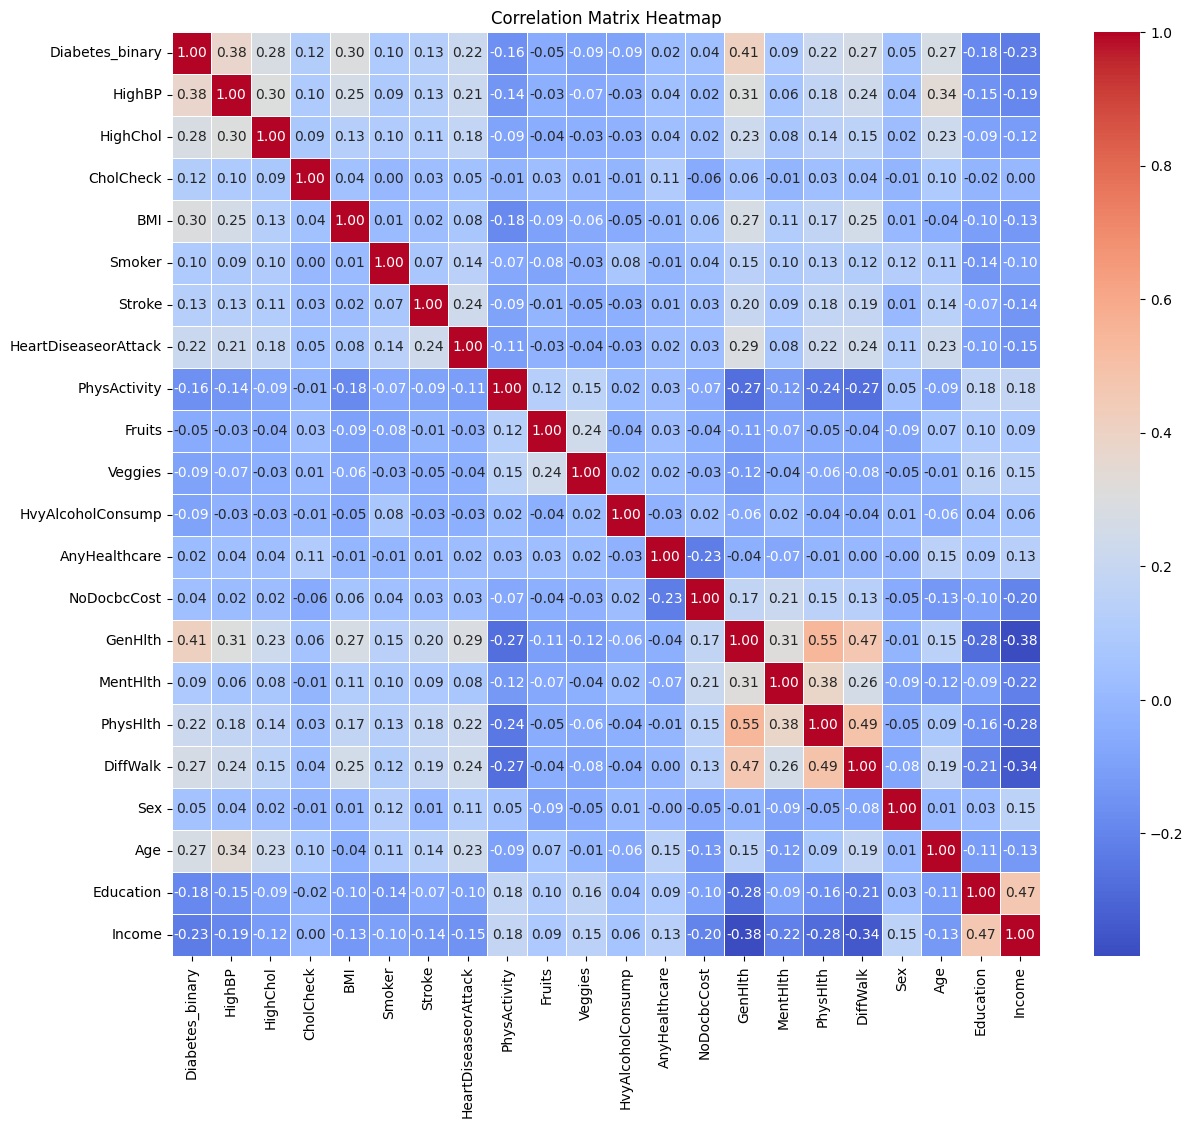

In [ ]:
# show the correlation between columns in the data
corr_matrix = diabetes_test_data.corr()

# Plot the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [ ]:
# Set target and features
target = "Diabetes_binary"
features = diabetes_train_data.columns.to_list()
features.remove(target)

X_train = diabetes_train_data[features].values
y_train = diabetes_train_data[target].values

X_test = diabetes_test_data[features].values
y_test = diabetes_test_data[target].values

# Print the dimensions of the feature matrix and the target vector, which are both NumPy arrays
print(f"X_train is a {type(X_train).__module__} {type(X_train).__name__} with shape {X_train.shape}:")
print(f"  num data instances: {X_train.shape[0]}")
print(f"  num features per instance: {X_train.shape[1]} \n" )
print(f"y_train is a {type(y_train).__module__} {type(y_train).__name__} with shape: {y_train.shape}")
print(f"  num data instances: {y_train.shape[0]}")
print(f"  num target values per instance: {len([y_train[0]])} \n")
print(f"X_test is a {type(X_test).__module__} {type(X_test).__name__} with shape {X_test.shape}:")
print(f"  num data instances: {X_test.shape[0]}")
print(f"  num features per instance: {X_test.shape[1]} \n")
print(f"y_test is a {type(y_test).__module__} {type(y_test).__name__} with shape: {y_test.shape}")
print(f"  num data instances: {y_test.shape[0]}")
print(f"  num target values per instance: {len([y_test[0]])}")



X_train is a numpy ndarray with shape (56553, 21):
  num data instances: 56553
  num features per instance: 21 

y_train is a numpy ndarray with shape: (56553,)
  num data instances: 56553
  num target values per instance: 1 

X_test is a numpy ndarray with shape (14139, 21):
  num data instances: 14139
  num features per instance: 21 

y_test is a numpy ndarray with shape: (14139,)
  num data instances: 14139
  num target values per instance: 1


In [ ]:
# Split training dataset into train and validation
seed = 42
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2, # 20% of 80% of dataset allocated to validation data
    shuffle=True, # (pseudo)randomly shuffle the data (again) before splitting
    random_state= seed
)

In [ ]:
# Convert the numpy assay to PyTorch tensors
# training
X_train_tensor = torch.tensor(X_train, dtype=torch.float)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

# validation
X_valid_tensor = torch.tensor(X_valid, dtype=torch.float)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)

# testing
X_test_tensor = torch.tensor(X_test, dtype=torch.float)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Display the shape of each tensor
print(f"""\
 --- tensor shapes ---
train features: {tuple(X_train_tensor.shape)}
train targets:  {tuple(y_train_tensor.shape)}
valid features: {tuple(X_valid_tensor.shape)}
valid targets:  {tuple(y_valid_tensor.shape)}
test features:  {tuple(X_test_tensor.shape)}
test targets:   {tuple(y_test_tensor.shape)}\
""")

 --- tensor shapes ---
train features: (45242, 21)
train targets:  (45242,)
valid features: (11311, 21)
valid targets:  (11311,)
test features:  (14139, 21)
test targets:   (14139,)


In [ ]:
# create data loaders
class DiabetesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
         return len(self.X)

    def __getitem__(self, idx):
        return (self.X[idx], self.y[idx])

In [ ]:
# create DiabetesDatasets objects for the training, validation, and testing
# datasets

train_dataset = DiabetesDataset(X_train_tensor, y_train_tensor)
valid_dataset = DiabetesDataset(X_valid_tensor, y_valid_tensor)
test_dataset = DiabetesDataset(X_test_tensor, y_test_tensor)

print(f"""\
Train length: {len(train_dataset)}
Train (x0,y0):\n{train_dataset[0]}\n
Valid length: {len(valid_dataset)}
Valid (x0,y0):\n{valid_dataset[0]}\n
Test length: {len(test_dataset)}
Test (x0,y0):\n{test_dataset[0]}\
""")

Train length: 45242
Train (x0,y0):
(tensor([ 1.,  1.,  1., 29.,  0.,  0.,  0.,  0.,  1.,  1.,  0.,  1.,  0.,  3.,
         0.,  0.,  0.,  1., 10.,  4.,  7.]), tensor(1))

Valid length: 11311
Valid (x0,y0):
(tensor([ 1.,  1.,  1., 32.,  1.,  0.,  0.,  1.,  1.,  1.,  0.,  1.,  0.,  2.,
         0.,  0.,  0.,  1.,  7.,  4.,  7.]), tensor(1))

Test length: 14139
Test (x0,y0):
(tensor([ 1.,  1.,  1., 36.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  1.,  0.,  3.,
         0.,  0.,  0.,  0.,  9.,  4.,  8.]), tensor(1))


In [ ]:
# create dataloader
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# define mlp for binary classification

class MLP(nn.Module):
  def __init__(self, input_size, hidden_size1, output_size): #removed hidden_size2 to see if that improves model validation. replace after testing
        super().__init__()

        self.linear1 = nn.Linear(input_size, hidden_size1)
        #self.linear2 = nn.Linear(hidden_size1, hidden_size2)
        self.linear_out = nn.Linear(hidden_size1, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        #self.batchnorm1 = nn.BatchNorm1d(hidden_size1)
        #self.batchnorm2 = nn.BatchNorm1d(hidden_size2)

  def forward(self, x):
        x = self.linear1(x)
        #x = self.batchnorm1(x)
        x = self.relu(x)
        #x = self.dropout(x)


        #x = self.linear2(x)
        #x = self.batchnorm2(x)
        x = self.relu(x)
        #x = self.dropout(x)

        x = self.linear_out(x)
        x = self.sigmoid(x)

        return x

In [ ]:
#model hyperparameters

input_size = X_train.shape[1]
hidden_size1 = 40
#hidden_size2 = 40
output_size = 1
epochs = 25

#initialize model
model = MLP(input_size, hidden_size1, output_size)
print(model)

#loss function
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adam optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reset/Clear history lists before starting the new run
train_loss, train_acc, valid_loss, valid_acc = [], [], [], []

MLP(
  (linear1): Linear(in_features=21, out_features=40, bias=True)
  (linear_out): Linear(in_features=40, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [ ]:
# train model

def train(model, train_dataloader, epochs):

    # move model to device
    model.to(device)

    train_loss = [] # store epoch loss
    train_acc = [] # store epoch accuracy

    for epoch in range(epochs):
        model.train()
        batch_loss = []
        batch_acc = []

        for i, (batch_X, batch_y) in enumerate(train_dataloader):
            batch_X = batch_X.to(device)
            # Targets need to be float and [batch_size, 1] for BCELoss
            batch_y = batch_y.to(device).float().unsqueeze(1)

            # forward pass
            outputs = model(batch_X)

            # calculate loss
            loss = criterion(outputs, batch_y)

            # Since model ends in Sigmoid, outputs are probabilities
            preds = (outputs > 0.5).float()
            acc = (preds == batch_y).float().mean().item()
            batch_acc.append(acc)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            #log loss
            batch_loss.append(loss.item())

        epoch_loss = np.array(batch_loss).mean()
        epoch_acc = np.array(batch_acc).mean()
        train_loss.append(epoch_loss)
        train_acc.append(epoch_acc)
        print(f"epoch [{epoch+1}/{epochs}], loss: {epoch_loss:.4f}, accuracy: {epoch_acc:.4f}")

    return train_loss, train_acc

In [ ]:
train_loss, train_acc = train(model, train_dataloader, epochs=epochs)

epoch [1/25], loss: 0.5435, accuracy: 0.7248
epoch [2/25], loss: 0.5281, accuracy: 0.7365
epoch [3/25], loss: 0.5237, accuracy: 0.7393
epoch [4/25], loss: 0.5199, accuracy: 0.7425
epoch [5/25], loss: 0.5178, accuracy: 0.7433
epoch [6/25], loss: 0.5159, accuracy: 0.7455
epoch [7/25], loss: 0.5159, accuracy: 0.7463
epoch [8/25], loss: 0.5163, accuracy: 0.7449
epoch [9/25], loss: 0.5137, accuracy: 0.7482
epoch [10/25], loss: 0.5147, accuracy: 0.7459
epoch [11/25], loss: 0.5127, accuracy: 0.7486
epoch [12/25], loss: 0.5133, accuracy: 0.7471
epoch [13/25], loss: 0.5127, accuracy: 0.7477
epoch [14/25], loss: 0.5134, accuracy: 0.7475
epoch [15/25], loss: 0.5120, accuracy: 0.7473
epoch [16/25], loss: 0.5139, accuracy: 0.7472
epoch [17/25], loss: 0.5124, accuracy: 0.7482
epoch [18/25], loss: 0.5116, accuracy: 0.7484
epoch [19/25], loss: 0.5115, accuracy: 0.7488
epoch [20/25], loss: 0.5122, accuracy: 0.7480
epoch [21/25], loss: 0.5125, accuracy: 0.7492
epoch [22/25], loss: 0.5125, accuracy: 0.74

In [ ]:
# visualizing model loss and accuracy
def plot_curves(epochs, loss, acc):

    # Create a figure and a set of subplots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

    # Plot on the loss subplot
    axes[0].plot(range(epochs), np.array(loss))
    axes[0].set_ylabel("loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_title("Training Loss")

    # Plot on the accuracy subplot
    axes[1].plot(range(epochs), np.array(acc))
    axes[1].set_ylabel("accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_title("Training Accuracy")

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Show the plot
    plt.show()

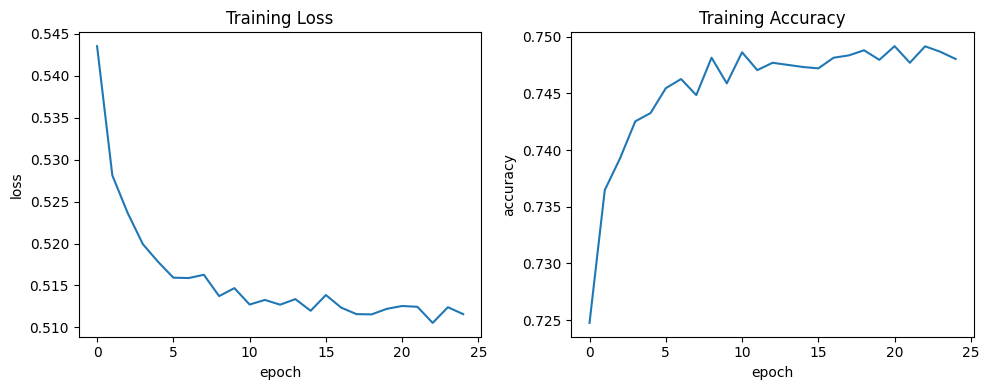

In [ ]:
plot_curves(epochs, train_loss, train_acc)

In [ ]:
# model and testing
def test(model, test_dataloader, print_report=True):

    model.eval() # set the model to eval mode

    with torch.no_grad(): # don't compute gradients
        ys_hat = []       # store predictions
        ys = []           # store desired output values
        eval_loss = []    # store loss

        for batch_X, batch_y in valid_dataloader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device).float().unsqueeze(1)

            # forward pass
            outputs = model(batch_X)

            # calculate and log loss
            loss = criterion(outputs, batch_y)
            eval_loss.append(loss.item())

            # use 0.5 threshold for Sigmoid outputs
            preds = (outputs > 0.5).float()
            ys_hat.append(preds.cpu().numpy())
            ys.append(batch_y.cpu().numpy())

        # compute the average loss and acc
        eval_loss = np.mean(eval_loss)
        ys_hat = np.concatenate(ys_hat)
        ys = np.concatenate(ys)
        ys_hat = (ys_hat>0.5).astype(float)
        eval_acc = (ys_hat == ys).mean()

    print(f"test loss: {eval_loss:.4f}, test accuracy: {eval_acc:.4f}\n")

    # print out a classification report
    if print_report:
        print(classification_report(ys, ys_hat, zero_division=0))

    return eval_acc, eval_loss

In [ ]:
test_acc, test_loss = test(model, test_dataloader)

test loss: 0.4977, test accuracy: 0.7536

              precision    recall  f1-score   support

         0.0       0.77      0.72      0.74      5657
         1.0       0.74      0.79      0.76      5654

    accuracy                           0.75     11311
   macro avg       0.75      0.75      0.75     11311
weighted avg       0.75      0.75      0.75     11311



In [ ]:
# model evaluation
def train_eval(model, train_dataloader, valid_dataloader, epochs):

    # move model to device
    model.to(device)

    train_loss = [] # store epoch training loss
    train_acc = [] # store epoch training accuracy
    valid_loss = [] # store epoch validation loss
    valid_acc = [] # store epoch validation accuracy

    for epoch in range(epochs):

        model.train() # set the model to train mode

        batch_loss = []
        batch_acc = []

        for i, (batch_X, batch_y) in enumerate(train_dataloader):

            # move data to device
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device).float().unsqueeze(1)

            # forward pass
            outputs = model(batch_X)

            # calculate loss
            loss = criterion(outputs, batch_y)

            # compute accuracy and log
            preds = (outputs > 0.5).float()
            acc = (preds == batch_y).float().mean().item()
            batch_acc.append(acc)

            # backpropagation and parameter update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # log batch loss
            batch_loss.append(loss.item())

        # epoch complete – log and print the average loss and average accuracy across the epoch
        epoch_loss = np.array(batch_loss).mean()
        epoch_acc = np.array(batch_acc).mean()
        train_loss.append(epoch_loss)
        train_acc.append(epoch_acc)
        print(f"epoch [{epoch+1}/{epochs}], loss: {epoch_loss:.4f}, accuracy: {epoch_acc:.4f}")

        # FIX: Changed 'eval' to 'test' to match the renamed function in cell IHkjpm-7ZDzu
        acc, loss = test(model, valid_dataloader, print_report=False)

        # log validation loss and accuracy
        valid_loss.append(loss)
        valid_acc.append(acc)

    # all epochs complete – return loss and accuracy logs to caller
    return train_loss, train_acc, valid_loss, valid_acc

In [ ]:
# Model hyperparameters
input_size = X_train.shape[1]  # Number of input features (21)
hidden_size1 = 256
#hidden_size2 = 128
output_size =  1
epochs = 25

# Initialize the model, loss function, and optimizer
model = MLP(input_size, hidden_size1, output_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adam optimizer

# get device
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Let's train and evaluation the model
train_loss, train_acc, eval_loss, eval_acc = train_eval(model, train_dataloader, valid_dataloader, epochs = epochs)


epoch [1/25], loss: 0.5582, accuracy: 0.7178
test loss: 0.5129, test accuracy: 0.7450

epoch [2/25], loss: 0.5303, accuracy: 0.7362
test loss: 0.5210, test accuracy: 0.7430

epoch [3/25], loss: 0.5270, accuracy: 0.7380
test loss: 0.5040, test accuracy: 0.7544

epoch [4/25], loss: 0.5219, accuracy: 0.7421
test loss: 0.5069, test accuracy: 0.7501

epoch [5/25], loss: 0.5219, accuracy: 0.7428
test loss: 0.5109, test accuracy: 0.7482

epoch [6/25], loss: 0.5192, accuracy: 0.7410
test loss: 0.5104, test accuracy: 0.7553

epoch [7/25], loss: 0.5182, accuracy: 0.7440
test loss: 0.5074, test accuracy: 0.7503

epoch [8/25], loss: 0.5168, accuracy: 0.7447
test loss: 0.5038, test accuracy: 0.7567

epoch [9/25], loss: 0.5159, accuracy: 0.7456
test loss: 0.5050, test accuracy: 0.7545

epoch [10/25], loss: 0.5157, accuracy: 0.7465
test loss: 0.5190, test accuracy: 0.7430

epoch [11/25], loss: 0.5145, accuracy: 0.7455
test loss: 0.5133, test accuracy: 0.7408

epoch [12/25], loss: 0.5146, accuracy: 0.

In [ ]:
def plot_curves2(epochs, loss_list, acc_list, name_list):
    # epochs: the number of epochs
    # loss_list: multiple lists of loss values
    # acc_list: multiple lists of accuracy values
    # name_list: the name for each list for plot legend

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

    # plot the loss
    for name, loss in zip(name_list, loss_list):
        axes[0].plot(range(epochs), np.array(loss), label = name)
    axes[0].set_ylabel("loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_title("Loss")
    axes[0].legend()

    # plot the accuracy
    for name, acc in zip(name_list, acc_list):
        axes[1].plot(range(epochs), np.array(acc), label = name)
    axes[1].set_ylabel("accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_title("Accuracy")
    axes[1].legend()

    plt.tight_layout() # prevent overlapping
    plt.show()

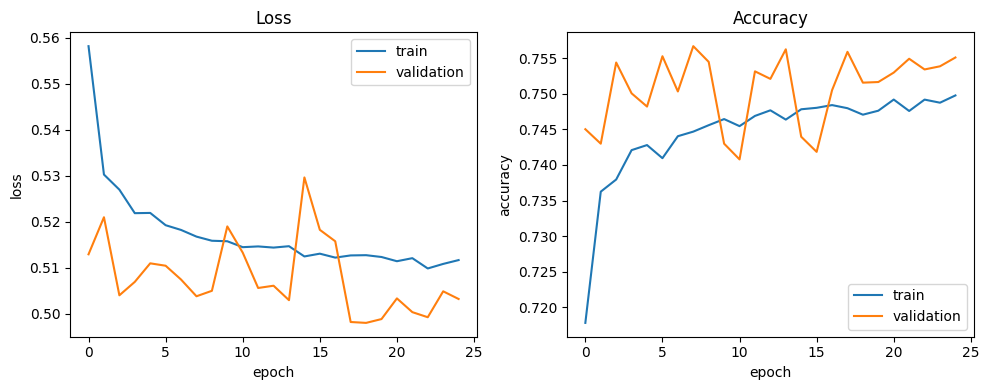

In [ ]:
plot_curves2(epochs, [train_loss, eval_loss], [train_acc, eval_acc], ["train", "validation"])

## Batch normalization to improve overfitting

In [ ]:
class MLP_Dropout(nn.Module):

    # __init__ defines all layers
    def __init__(self, input_size, hidden_size, output_size, dropout_rate=0.3):
        super(MLP_Dropout, self).__init__()

        self.seq = nn.Sequential(
            nn.Linear(input_size, hidden_size),   # Input to hidden layer
            nn.Dropout(dropout_rate),             # Dropout for regularization
            nn.ReLU(),                            # Activation
            nn.Linear(hidden_size, output_size),   # Output layer (no activation here)
            nn.Sigmoid()                                # Sigmoid activation

        )

    # forward pass
    def forward(self, x):
        return self.seq(x)


epoch [1/25], loss: 0.5647, accuracy: 0.7162
test loss: 0.5198, test accuracy: 0.7452

epoch [2/25], loss: 0.5397, accuracy: 0.7296
test loss: 0.5141, test accuracy: 0.7434

epoch [3/25], loss: 0.5341, accuracy: 0.7341
test loss: 0.5087, test accuracy: 0.7470

epoch [4/25], loss: 0.5356, accuracy: 0.7324
test loss: 0.5271, test accuracy: 0.7386

epoch [5/25], loss: 0.5350, accuracy: 0.7347
test loss: 0.5183, test accuracy: 0.7410

epoch [6/25], loss: 0.5328, accuracy: 0.7377
test loss: 0.5255, test accuracy: 0.7418

epoch [7/25], loss: 0.5337, accuracy: 0.7370
test loss: 0.5093, test accuracy: 0.7474

epoch [8/25], loss: 0.5325, accuracy: 0.7377
test loss: 0.5130, test accuracy: 0.7423

epoch [9/25], loss: 0.5325, accuracy: 0.7385
test loss: 0.5075, test accuracy: 0.7517

epoch [10/25], loss: 0.5312, accuracy: 0.7387
test loss: 0.5252, test accuracy: 0.7497

epoch [11/25], loss: 0.5302, accuracy: 0.7386
test loss: 0.5143, test accuracy: 0.7472

epoch [12/25], loss: 0.5305, accuracy: 0.

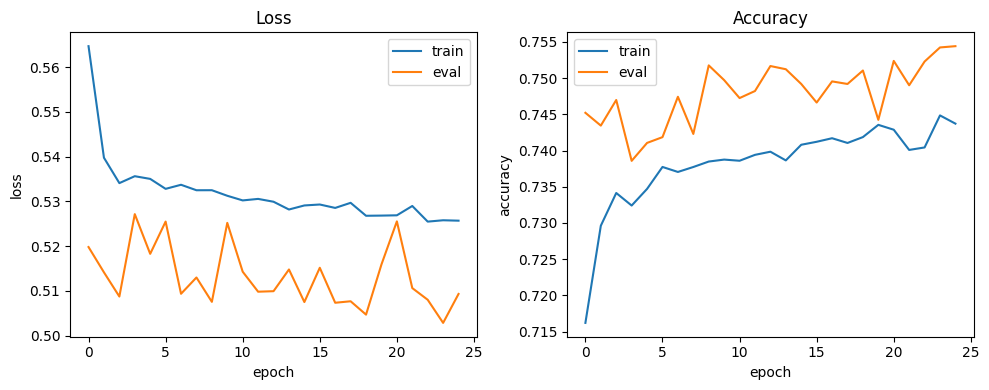

test loss: 0.5093, test accuracy: 0.7544

              precision    recall  f1-score   support

         0.0       0.76      0.75      0.75      5657
         1.0       0.75      0.76      0.76      5654

    accuracy                           0.75     11311
   macro avg       0.75      0.75      0.75     11311
weighted avg       0.75      0.75      0.75     11311



In [ ]:
# Model hyperparameters
input_size = X_train.shape[1]  # Number of input features (10)
hidden_size = 256
output_size = 1
epochs = 25

# Initialize the model, loss function, and optimizer
model = MLP_Dropout(input_size, hidden_size, output_size, dropout_rate=0.2)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adam optimizer

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
train_loss, train_acc, eval_loss, eval_acc = train_eval(model, train_dataloader, valid_dataloader, epochs = epochs)
plot_curves2(epochs, [train_loss, eval_loss], [train_acc, eval_acc], ['train', 'eval'])
test_acc, test_loss = test(model, test_dataloader)

In [ ]:
def train_eval_early_stopping(model, train_dataloader, valid_dataloader, epochs = 25,
                              patience = 5,
                              model_save_path = 'best.pth'
                             ):

    train_loss = []
    train_acc = []

    eval_loss_hist = []
    eval_acc_hist = []

    best_loss = np.inf
    worse_cnt  = 0

    model.to(device)

    for epoch in range(epochs):

        model.train()
        batch_loss = []
        batch_acc = []

        for batch_X, batch_y in train_dataloader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device).float().unsqueeze(1)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            pred = (outputs>0.5).float()
            acc = (pred == batch_y).float().mean().item()
            batch_acc.append(acc)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_loss.append(loss.item())

        epoch_loss = np.array(batch_loss).mean()
        epoch_acc = np.array(batch_acc).mean()

        train_loss.append(epoch_loss)
        train_acc.append(epoch_acc)

        # Use the 'test' function for validation
        acc, loss = test(model, valid_dataloader, print_report = False)

        eval_loss_hist.append(loss)
        eval_acc_hist.append(acc)

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, Val Loss: {loss:.4f}')

        if loss < best_loss:
            best_loss = loss
            worse_cnt  = 0
            torch.save(model.state_dict(), model_save_path )
        else:
            worse_cnt += 1
            if worse_cnt >= patience:
                print("early stopping\n")
                model.load_state_dict(torch.load(model_save_path ))
                break

    return train_loss, train_acc, eval_loss_hist, eval_acc_hist

In [ ]:
# Use the 'test' function defined in cell IHkjpm-7ZDzu
test_acc, test_loss = test(model, test_dataloader, print_report=True)
print(f"Test loss:  {test_loss:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

if test_acc >= 0.70:
  print("Homework target reached: test accuracy is at least 70%.")
else:
  print("Homework target not reached: test accuracy is below 70%.")

test loss: 0.5093, test accuracy: 0.7544

              precision    recall  f1-score   support

         0.0       0.76      0.75      0.75      5657
         1.0       0.75      0.76      0.76      5654

    accuracy                           0.75     11311
   macro avg       0.75      0.75      0.75     11311
weighted avg       0.75      0.75      0.75     11311

Test loss:  0.5093
Test accuracy:  0.7544
Homework target reached: test accuracy is at least 70%.
